# 01 EDA: Data loading and label sanity checks

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt


def _project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src").exists():
        return cwd
    if (cwd.parent / "src").exists():
        return cwd.parent
    raise RuntimeError("Cannot find project root with 'src' directory.")

PROJECT_ROOT = _project_root()
sys.path.append(str(PROJECT_ROOT / "src"))


In [2]:
from src.data import build_labeled_dataset

DATA_DIR = PROJECT_ROOT / "data"
LABELS_PATH = DATA_DIR / "combined_windows.json"

SERIES_FILES = [
    DATA_DIR / "realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv",
    DATA_DIR / "realAWSCloudwatch/ec2_disk_write_bytes_c0d644.csv",
]

dataset_df = build_labeled_dataset(
    series_paths=SERIES_FILES,
    labels_path=LABELS_PATH,
)

dataset_df.head()

,timestamp,value,series_id,is_incident
0,2014-02-14 14:30:00,0.132,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0
1,2014-02-14 14:35:00,0.134,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0
2,2014-02-14 14:40:00,0.134,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0
3,2014-02-14 14:45:00,0.134,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0
4,2014-02-14 14:50:00,0.134,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0


In [3]:
from src.data import summarize_series

summary_df = summarize_series(dataset_df)
summary_df

,series_id,rows,first_timestamp,last_timestamp,incident_points,min_value,max_value
0,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,4032,2014-02-14 14:30:00,2014-02-28 14:25:00,402,0.066,2.344000e+00
1,realAWSCloudwatch/ec2_disk_write_bytes_c0d644.csv,4032,2014-04-02 14:25:00,2014-04-16 14:20:00,405,0.000,8.639640e+08


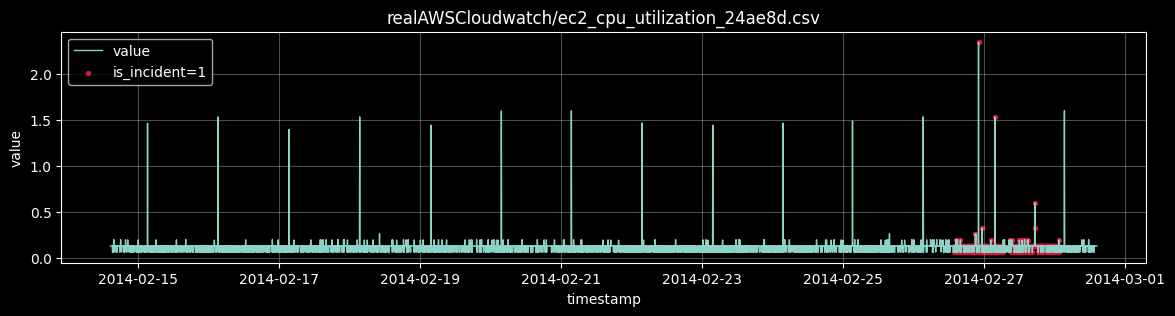

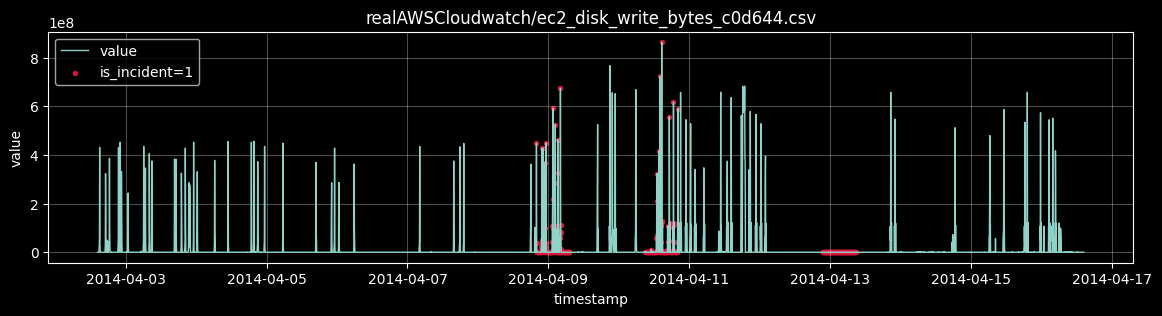

In [4]:
for series_id, series_df in dataset_df.groupby("series_id", sort=False):
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(series_df["timestamp"], series_df["value"], label="value", linewidth=1)

    incident_df = series_df[series_df["is_incident"] == 1]
    ax.scatter(
        incident_df["timestamp"],
        incident_df["value"],
        s=8,
        c="crimson",
        label="is_incident=1",
    )

    ax.set_title(series_id)
    ax.set_xlabel("timestamp")
    ax.set_ylabel("value")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.show()

In [5]:
dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8064 entries, 0 to 8063
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    8064 non-null   datetime64[us]
 1   value        8064 non-null   float64       
 2   series_id    8064 non-null   str           
 3   is_incident  8064 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 252.1 KB


In [30]:
from src.data import make_sliding_windows, normalize_series

WINDOW_SIZE = 24
HORIZON = 12

dataset_df = normalize_series(dataset_df)

training_df = make_sliding_windows(
    dataset=dataset_df,
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
)

print(f"training_df shape: {training_df[0].shape}")
print(f"positive class ratio: {training_df[1].mean():.4f}")
training_df[2].head()


training_df shape: (7994, 24, 1)
positive class ratio: 0.1078


,series_id,window_start,window_end,horizon_start,horizon_end
0,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,2014-02-14 14:30:00,2014-02-14 16:25:00,2014-02-14 16:30:00,2014-02-14 17:25:00
1,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,2014-02-14 14:35:00,2014-02-14 16:30:00,2014-02-14 16:35:00,2014-02-14 17:30:00
2,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,2014-02-14 14:40:00,2014-02-14 16:35:00,2014-02-14 16:40:00,2014-02-14 17:35:00
3,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,2014-02-14 14:45:00,2014-02-14 16:40:00,2014-02-14 16:45:00,2014-02-14 17:40:00
4,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,2014-02-14 14:50:00,2014-02-14 16:45:00,2014-02-14 16:50:00,2014-02-14 17:45:00
